<h1 style="text-align:center;">Customer Sales Analysis</h1>
<h3 style="text-align:center;">E-Commerce Sales Performance, Customer Behavior & Business Insights</h3>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

In [25]:


df = pd.read_csv("../data/raw/E-Commerce Sales Analytics.csv")

df.head()


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [26]:
df.shape

(5000, 12)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB


In [28]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [30]:
df.duplicated().sum()


np.int64(0)

In [31]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

df["order_date"].dtype

dtype('<M8[us]')

In [32]:
df["order_date"].isna().sum()

np.int64(0)

In [33]:
print("Quantity <= 0:", (df["quantity"] <= 0).sum())
print("Unit price <= 0:", (df["unit_price"] <= 0).sum())
print("Discount outside 0-1:", ((df["discount"] < 0) | (df["discount"] > 1)).sum())
print("Delivery days <= 0:", (df["delivery_days"] <= 0).sum())
print("Rating outside 1-5:", ((df["customer_rating"] < 1) | (df["customer_rating"] > 5)).sum())
print("Revenue < 0:", (df["revenue"] < 0).sum())

Quantity <= 0: 0
Unit price <= 0: 0
Discount outside 0-1: 0
Delivery days <= 0: 0
Rating outside 1-5: 0
Revenue < 0: 0


In [34]:
print("Product Categories:")
print(df["product_category"].unique())

print("\nRegions:")
print(df["region"].unique())

print("\nPayment Methods:")
print(df["payment_method"].unique())

Product Categories:
<StringArray>
['Beauty', 'Clothing', 'Electronics', 'Home']
Length: 4, dtype: str

Regions:
<StringArray>
['South', 'East', 'West', 'North']
Length: 4, dtype: str

Payment Methods:
<StringArray>
['Wallet', 'Card', 'COD']
Length: 3, dtype: str


In [35]:
df.describe()


,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2028-11-04 12:00:00,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
min,10001.000000,2022-01-01 00:00:00,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,2025-06-03 18:00:00,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,2028-11-04 12:00:00,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,2032-04-07 06:00:00,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,2035-09-09 00:00:00,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000
std,1443.520003,NaN,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219


In [36]:
expected_revenue = (
    df["quantity"] * df["unit_price"] * (1 - df["discount"])
).round(2)

revenue_difference = (
    df["revenue"] - expected_revenue
).abs()

print("Revenue mismatches:", (revenue_difference > 1).sum())

Revenue mismatches: 0


In [37]:
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_month_name"] = df["order_date"].dt.month_name()
df["order_weekday"] = df["order_date"].dt.day_name()

df["gross_amount"] = (
    df["quantity"] * df["unit_price"]
).round(2)

df["discount_amount"] = (
    df["gross_amount"] * df["discount"]
).round(2)

df["delivery_speed"] = pd.cut(
    df["delivery_days"],
    bins=[0, 3, 7, np.inf],
    labels=[
        "Fast (1-3 days)",
        "Standard (4-7 days)",
        "Slow (8+ days)"
    ]
)

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,order_year,order_month,order_month_name,order_weekday,gross_amount,discount_amount,delivery_speed
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,January,Saturday,2615.55,732.35,Slow (8+ days)
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,January,Sunday,334.18,30.08,Standard (4-7 days)
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022,1,January,Monday,933.84,289.49,Standard (4-7 days)
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,January,Tuesday,2622.35,52.45,Standard (4-7 days)
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,January,Wednesday,699.35,230.79,Standard (4-7 days)


In [38]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (5000, 19)

Missing values:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
order_year          0
order_month         0
order_month_name    0
order_weekday       0
gross_amount        0
discount_amount     0
delivery_speed      0
dtype: int64

Duplicate rows: 0


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[us]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   str           
 4   region            5000 non-null   str           
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   str           
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
 12  order_year        5000 non-null   int32         
 13  order_month       5000 non-null   int32         
 14  order_month_name  5000 non-null   s

In [51]:
df["order_year"].value_counts().sort_index()

order_year
2022    365
2023    365
2024    366
2025    365
2026    365
2027    365
2028    366
2029    365
2030    365
2031    365
2032    366
2033    365
2034    365
2035    252
Name: count, dtype: int64

In [52]:
today = pd.Timestamp.today().normalize()

future_dates = df[df["order_date"] > today]

print("Today's date:", today)
print("Future records:", len(future_dates))
print("Latest date:", df["order_date"].max())

Today's date: 2026-09-07 00:00:00
Future records: 3289
Latest date: 2035-09-09 00:00:00


In [40]:
df.describe()

,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue,order_year,order_month,gross_amount,discount_amount
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2028-11-04 12:00:00,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148,2028.352800,6.430600,1248.004392,226.049212
min,10001.000000,2022-01-01 00:00:00,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000,2022.000000,1.000000,15.150000,0.000000
25%,11250.750000,2025-06-03 18:00:00,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500,2025.000000,3.000000,440.762500,49.512500
50%,12500.500000,2028-11-04 12:00:00,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000,2028.000000,6.000000,984.740000,134.915000
75%,13750.250000,2032-04-07 06:00:00,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000,2032.000000,9.000000,1854.877500,319.397500
max,15000.000000,2035-09-09 00:00:00,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000,2035.000000,12.000000,4196.500000,1424.050000
std,1443.520003,NaN,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219,3.954827,3.427584,990.405014,242.674179


In [41]:
print("Total Orders:", df["order_id"].nunique())
print("Unique Customers:", df["customer_id"].nunique())
print("Total Revenue:", df["revenue"].sum())
print("Average Order Revenue:", df["revenue"].mean())

Total Orders: 5000
Unique Customers: 989
Total Revenue: 5109775.74
Average Order Revenue: 1021.955148


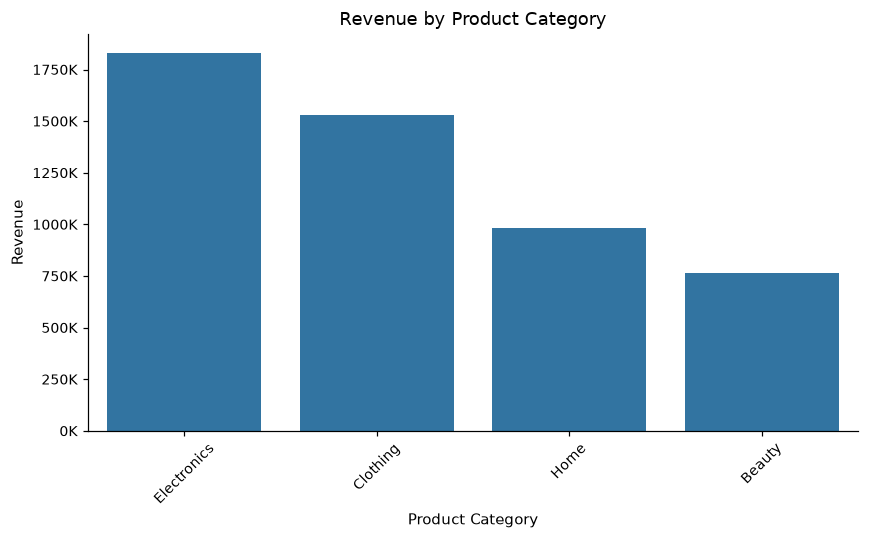

In [43]:
category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

# Format Y-axis in thousands
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

plt.tight_layout()
plt.show()

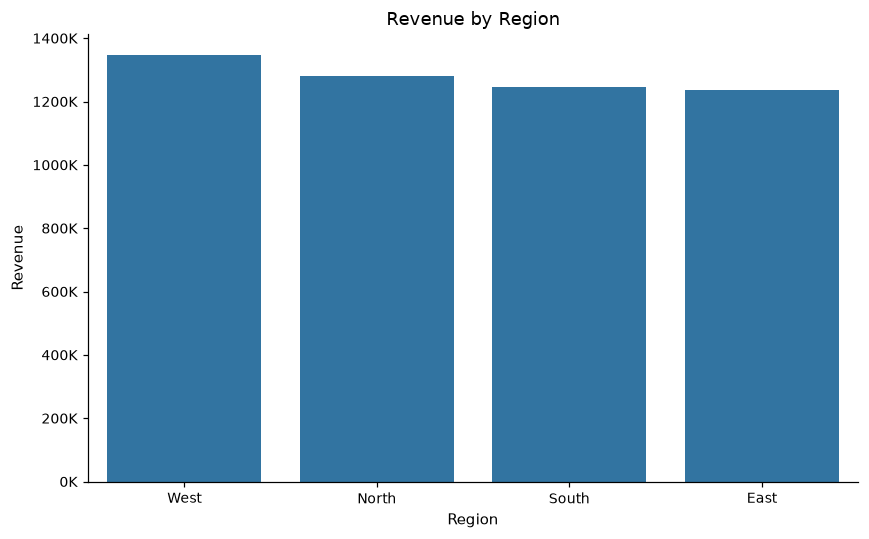

In [44]:
region_revenue = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=region_revenue.index,
    y=region_revenue.values
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

plt.tight_layout()
plt.show()

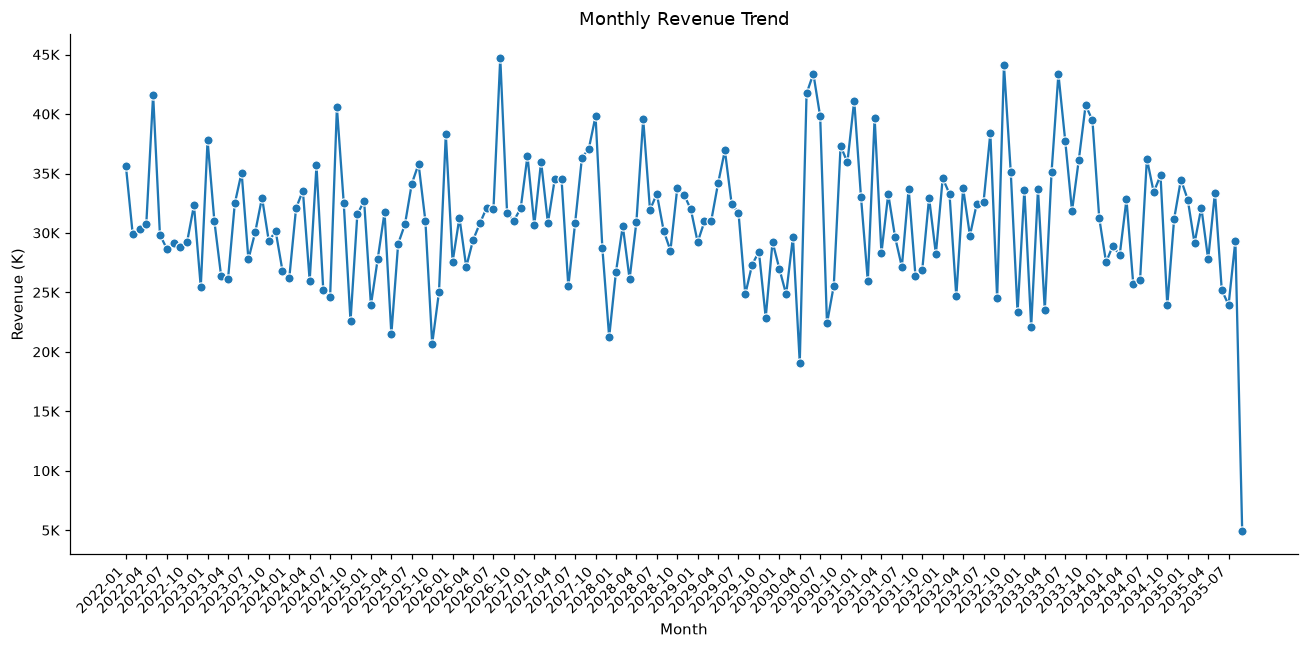

In [46]:
monthly_revenue = (
    df.groupby(df["order_date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_revenue
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    x=monthly_revenue.index.astype(str),
    y=monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (K)")

# Show every 3rd month label
plt.xticks(
    ticks=range(0, len(monthly_revenue), 3),
    labels=monthly_revenue.index.astype(str)[::3],
    rotation=45,
    ha="right"
)

# Display revenue in thousands
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

plt.tight_layout()
plt.show()

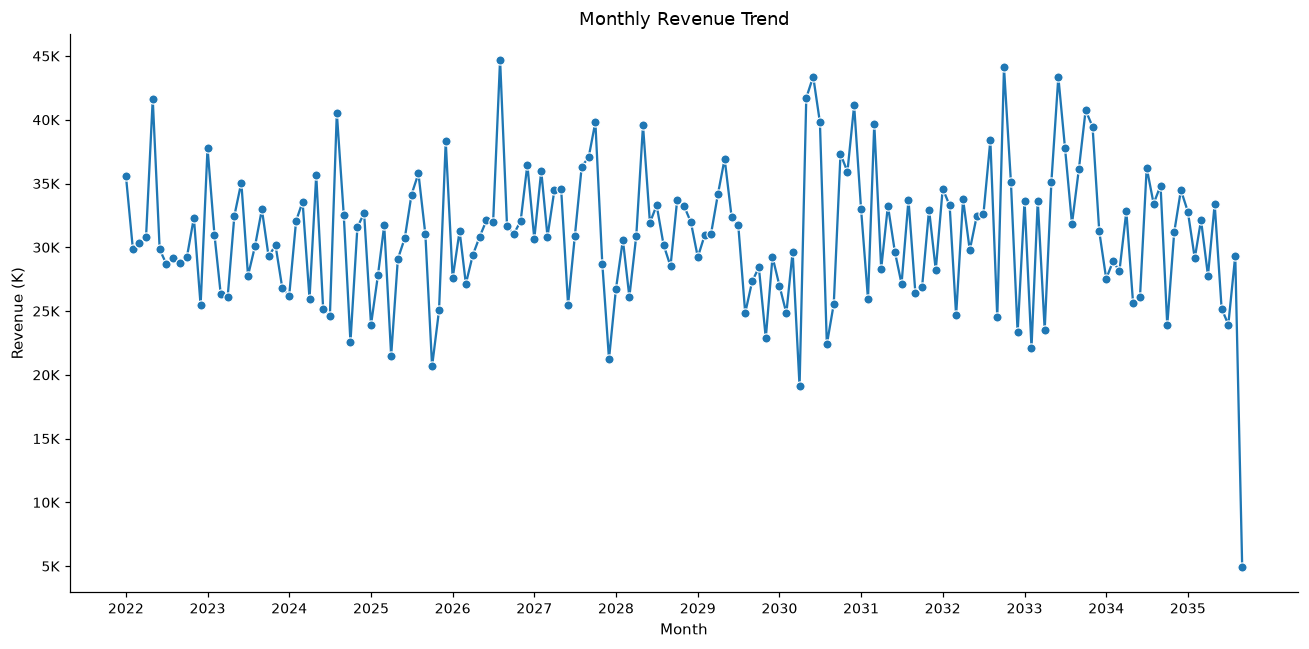

In [50]:
plt.figure(figsize=(12, 6))

x = monthly_revenue.index.to_timestamp()

ax = sns.lineplot(
    x=x,
    y=monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (K)")

# Show one label per year
plt.xticks(
    ticks=x[::12],
    labels=x.strftime("%Y")[::12],
    rotation=0
)

# Display revenue in thousands
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

plt.tight_layout()
plt.show()

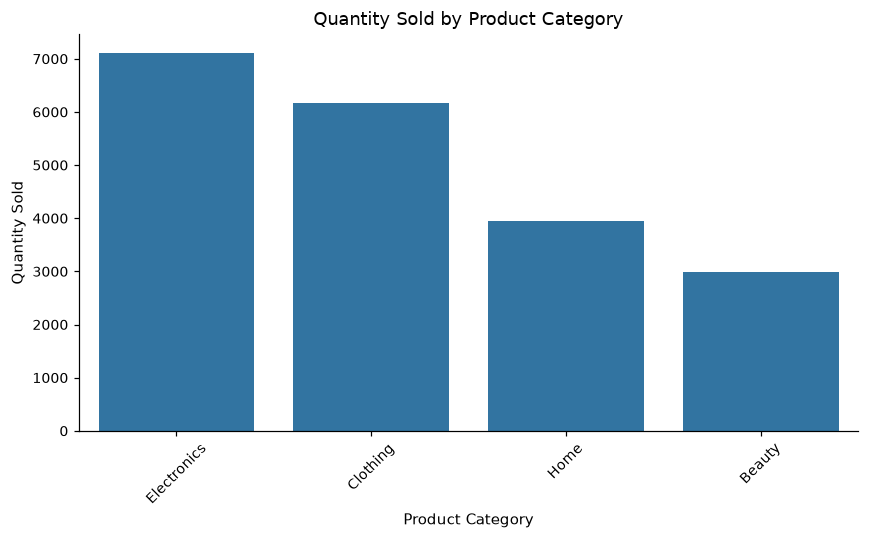

In [53]:
category_quantity = (
    df.groupby("product_category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

category_quantity
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

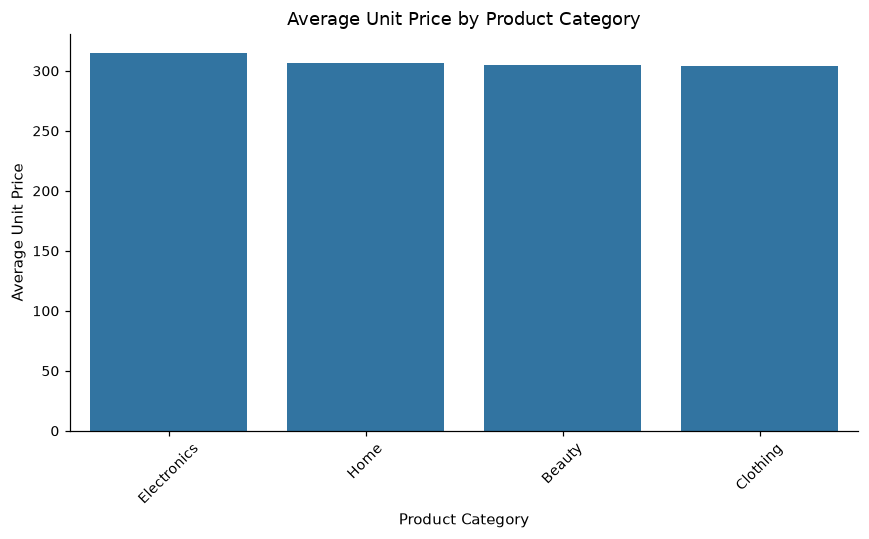

In [54]:
category_avg_price = (
    df.groupby("product_category")["unit_price"]
    .mean()
    .sort_values(ascending=False)
)

category_avg_price
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=category_avg_price.index,
    y=category_avg_price.values
)

plt.title("Average Unit Price by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Unit Price")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

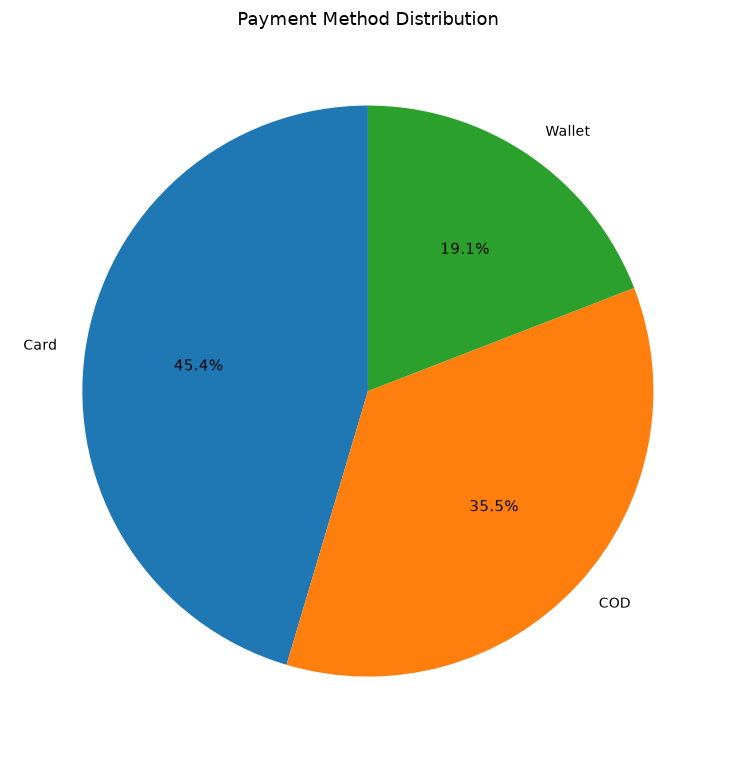

In [55]:
payment_counts = df["payment_method"].value_counts()

payment_counts
plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")

plt.tight_layout()
plt.show()

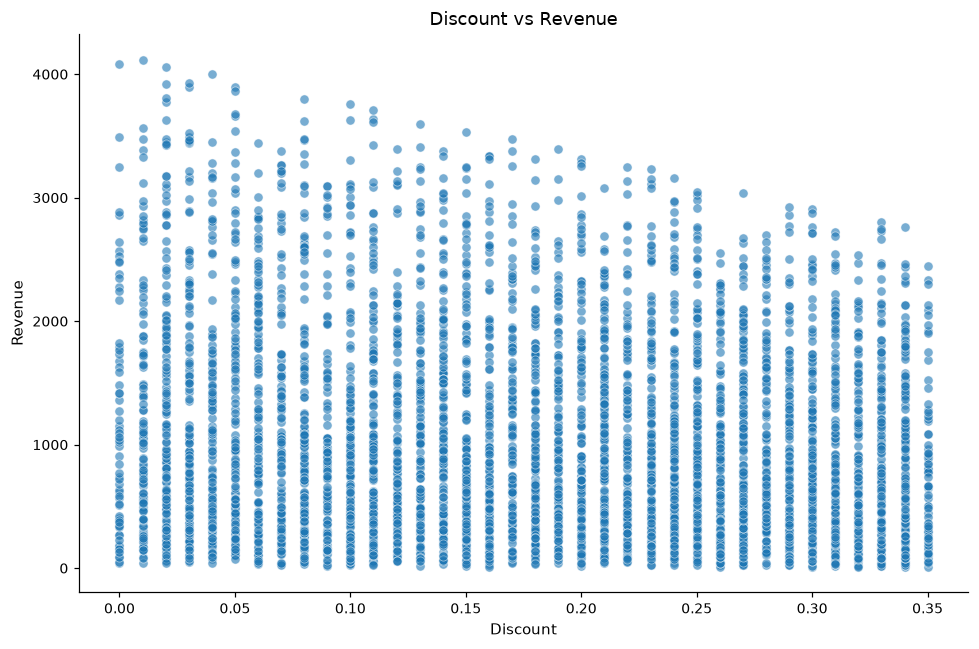

In [56]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="discount",
    y="revenue",
    alpha=0.6
)

plt.title("Discount vs Revenue")
plt.xlabel("Discount")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

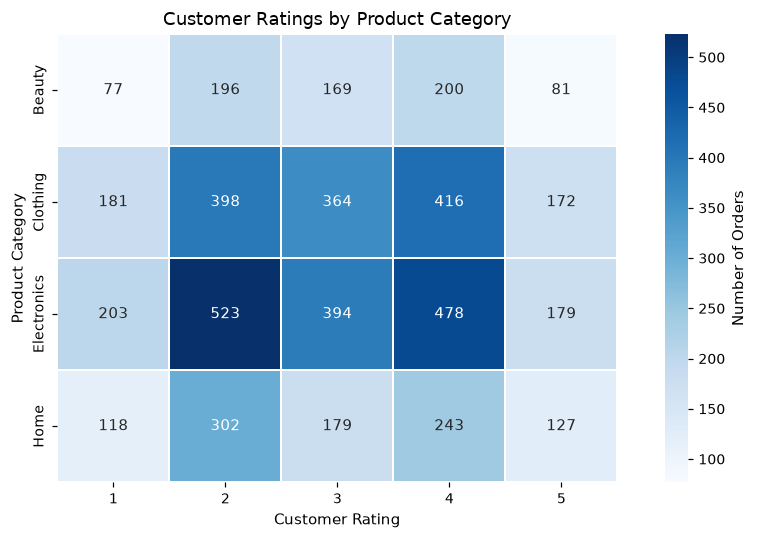

In [59]:

df["rating_group"] = df["customer_rating"].round().clip(1, 5)


rating_by_category = pd.crosstab(
    df["product_category"],
    df["rating_group"]
)

rating_by_category = rating_by_category.reindex(
    columns=[1, 2, 3, 4, 5],
    fill_value=0
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    rating_by_category,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Number of Orders"}
)

plt.title("Customer Ratings by Product Category")
plt.xlabel("Customer Rating")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

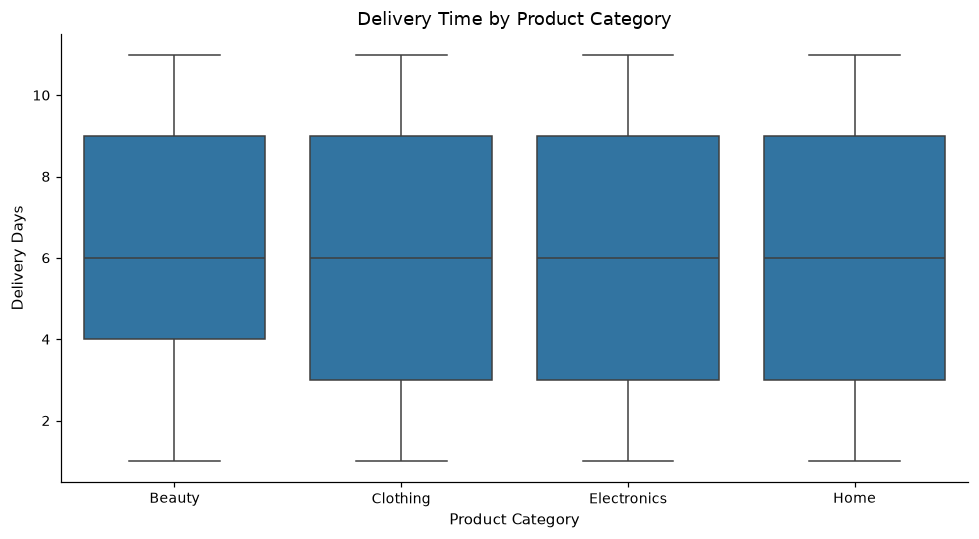

In [60]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="product_category",
    y="delivery_days"
)

plt.title("Delivery Time by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Delivery Days")

plt.tight_layout()
plt.show()

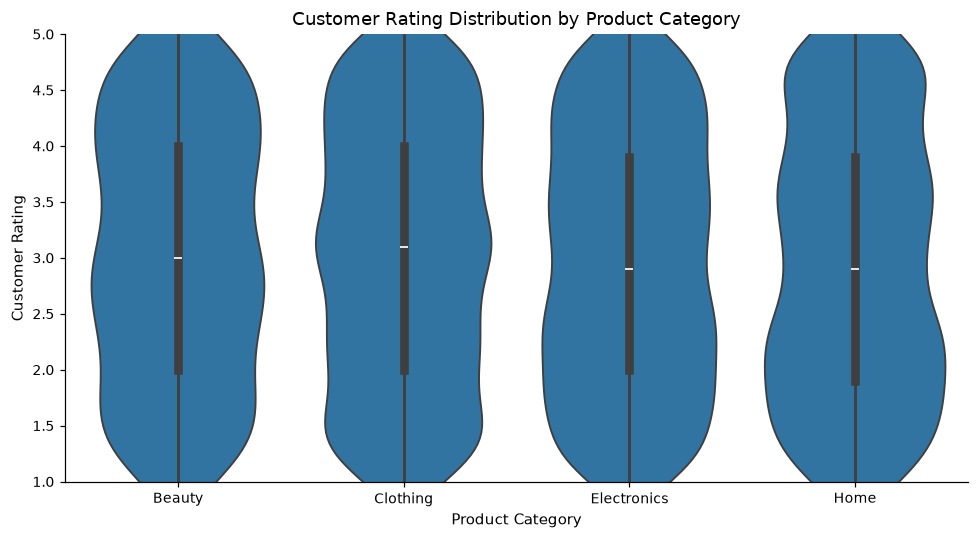

In [61]:
plt.figure(figsize=(9, 5))

sns.violinplot(
    data=df,
    x="product_category",
    y="customer_rating",
    inner="box"
)

plt.title("Customer Rating Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Customer Rating")

plt.ylim(1, 5)

plt.tight_layout()
plt.show()

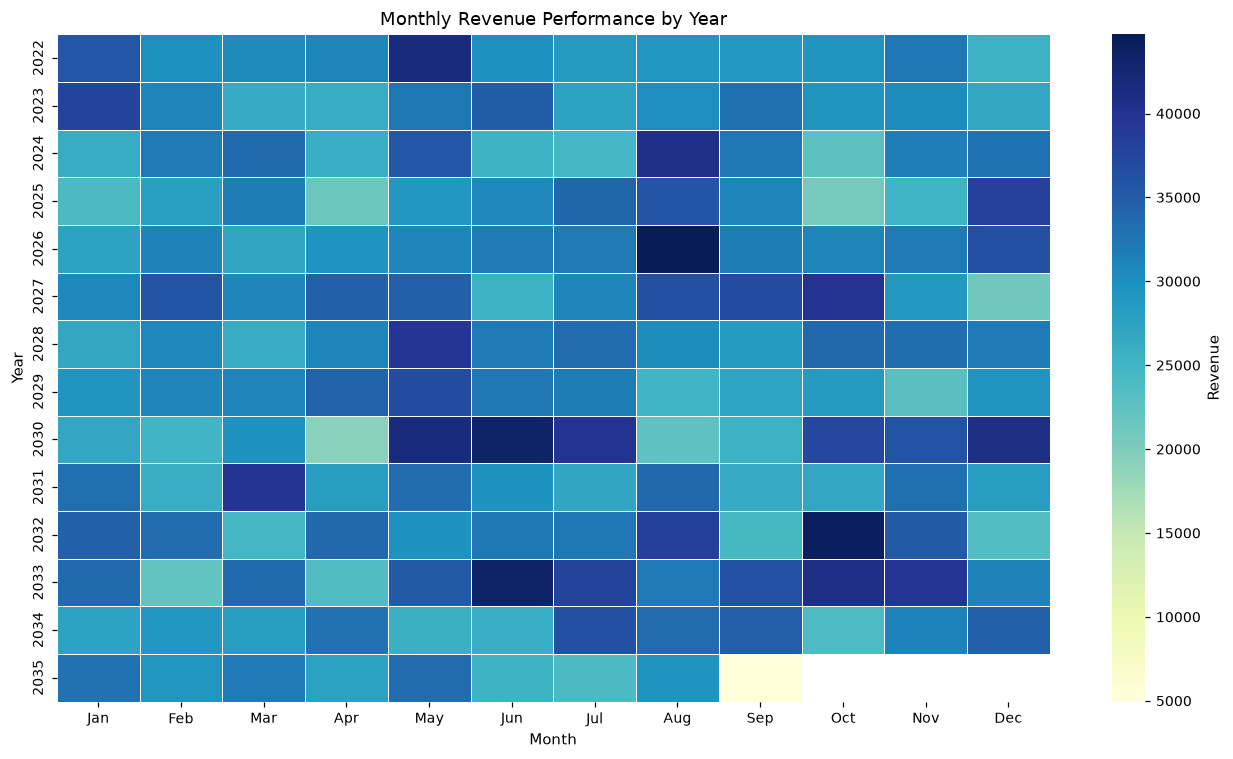

In [62]:
monthly_year_revenue = (
    df.pivot_table(
        index="order_year",
        columns="order_month",
        values="revenue",
        aggfunc="sum"
    )
)

monthly_year_revenue.columns = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 7))

sns.heatmap(
    monthly_year_revenue,
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Revenue"}
)

plt.title("Monthly Revenue Performance by Year")
plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

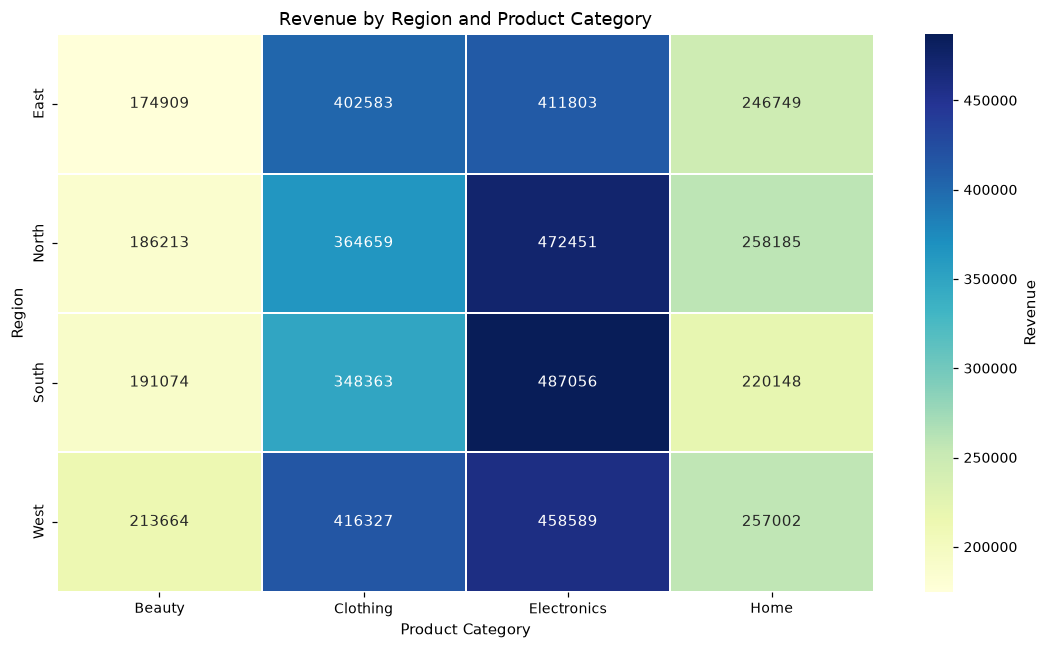

In [63]:
region_category_revenue = pd.pivot_table(
    df,
    index="region",
    columns="product_category",
    values="revenue",
    aggfunc="sum"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    region_category_revenue,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Revenue"}
)

plt.title("Revenue by Region and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

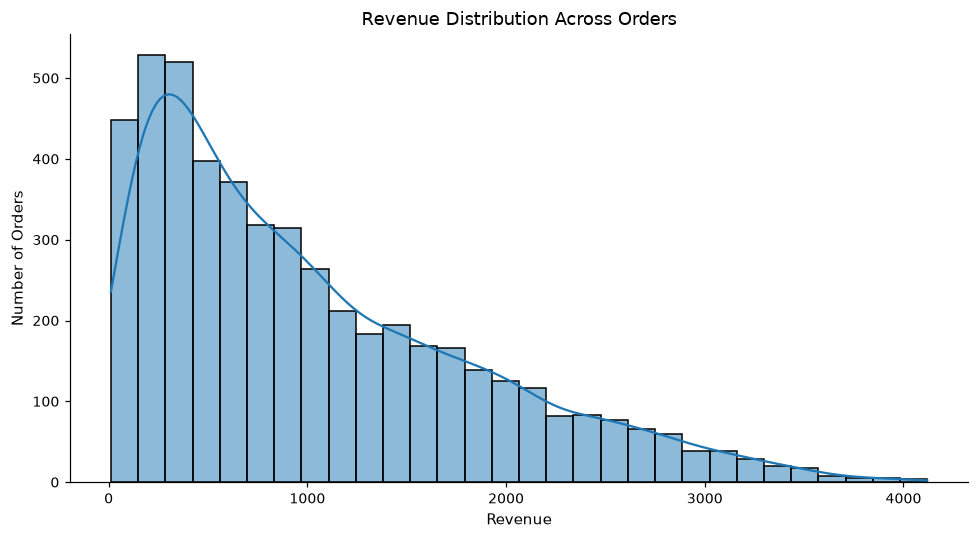

In [64]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="revenue",
    bins=30,
    kde=True
)

plt.title("Revenue Distribution Across Orders")
plt.xlabel("Revenue")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

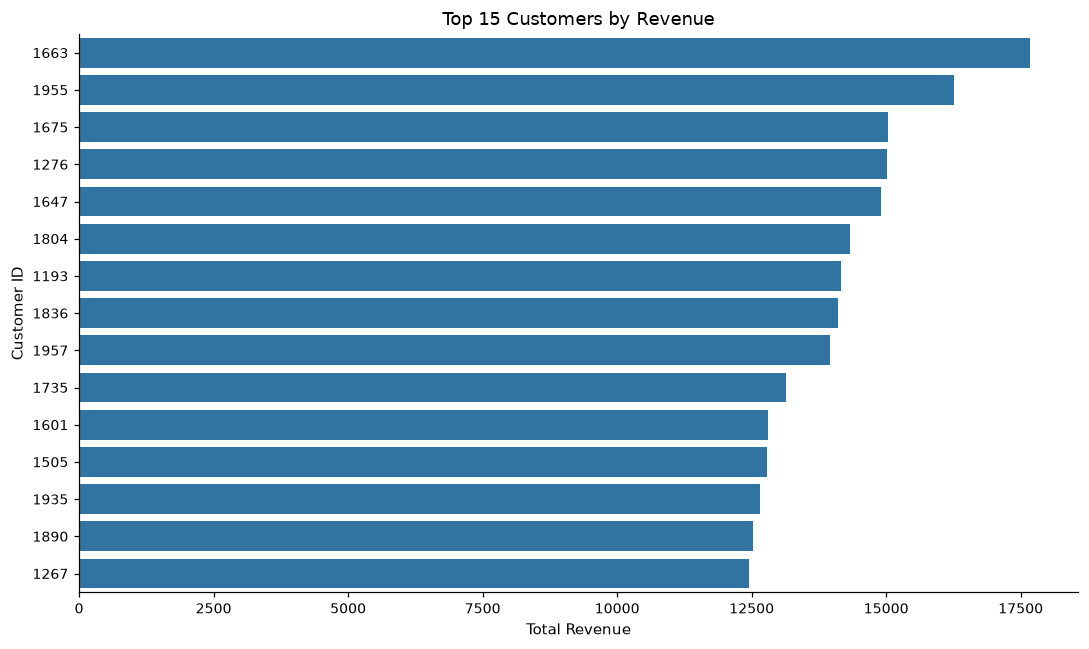

In [65]:
customer_revenue = (
    df.groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_customers = customer_revenue.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Top 15 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

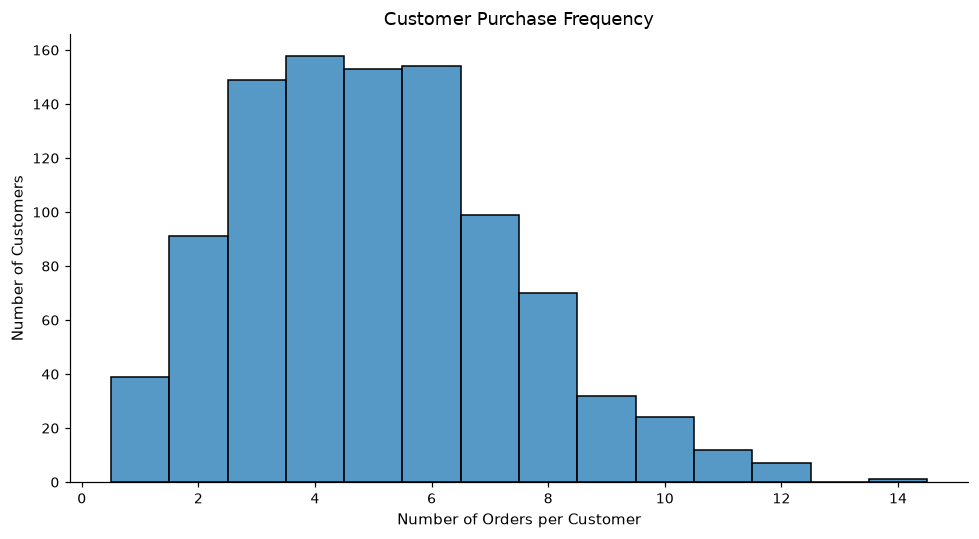

In [66]:
customer_order_frequency = (
    df.groupby("customer_id")["order_id"]
    .nunique()
)

plt.figure(figsize=(9, 5))

sns.histplot(
    customer_order_frequency,
    bins=15,
    discrete=True
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

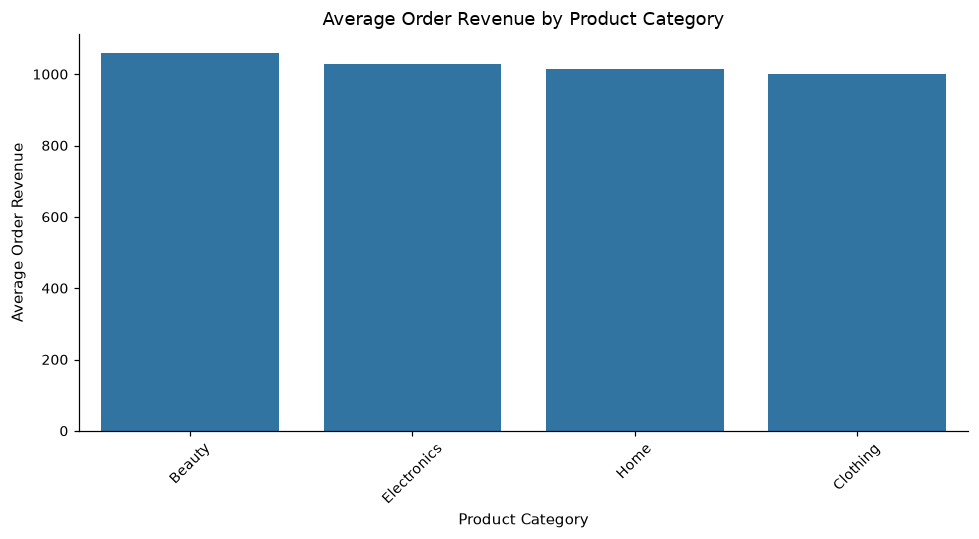

In [67]:
avg_order_revenue_category = (
    df.groupby("product_category")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=avg_order_revenue_category.index,
    y=avg_order_revenue_category.values
)

plt.title("Average Order Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Order Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

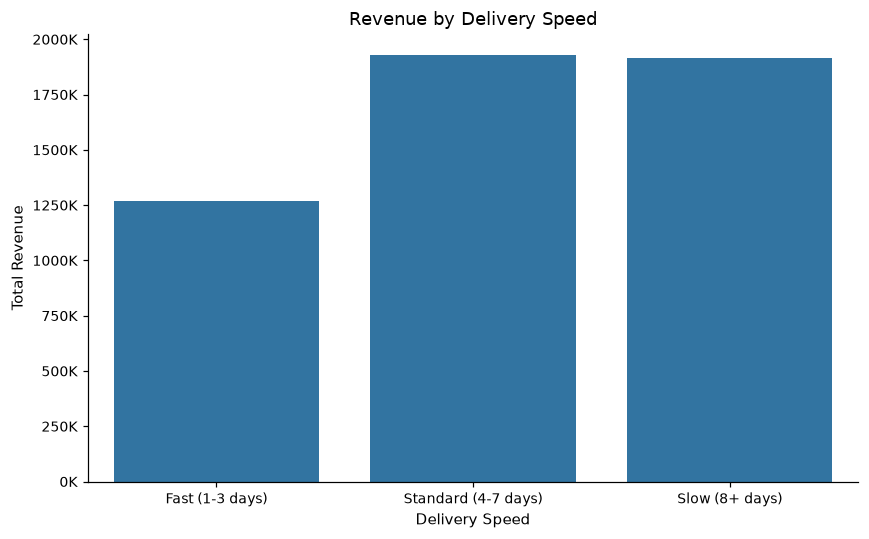

In [68]:
delivery_speed_revenue = (
    df.groupby("delivery_speed", observed=False)["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=delivery_speed_revenue.index,
    y=delivery_speed_revenue.values
)

plt.title("Revenue by Delivery Speed")
plt.xlabel("Delivery Speed")
plt.ylabel("Total Revenue")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

plt.tight_layout()
plt.show()

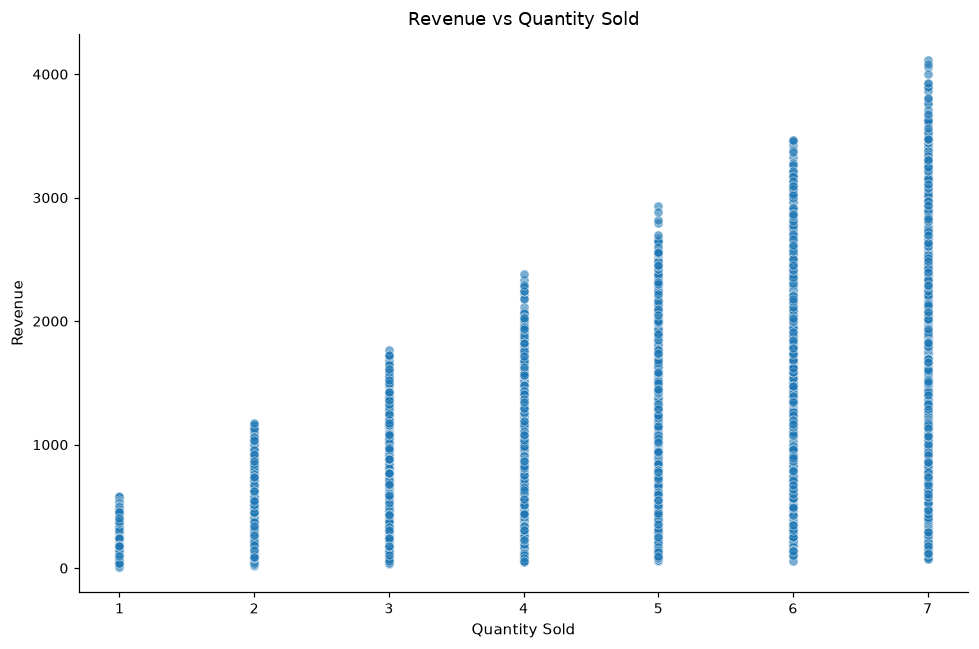

In [69]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="quantity",
    y="revenue",
    alpha=0.6
)

plt.title("Revenue vs Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

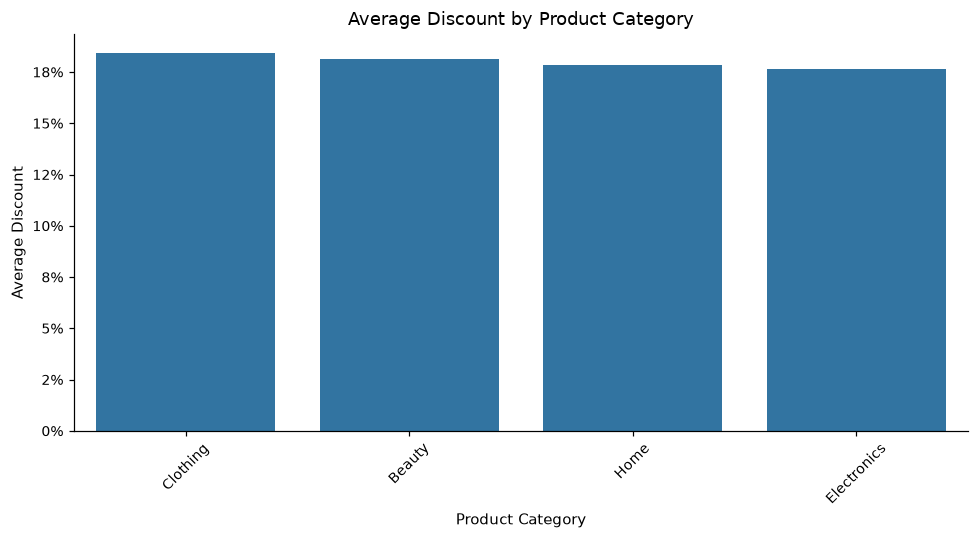

In [70]:
avg_discount_category = (
    df.groupby("product_category")["discount"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=avg_discount_category.index,
    y=avg_discount_category.values
)

plt.title("Average Discount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Discount")

plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x:.0%}")
)

plt.tight_layout()
plt.show()

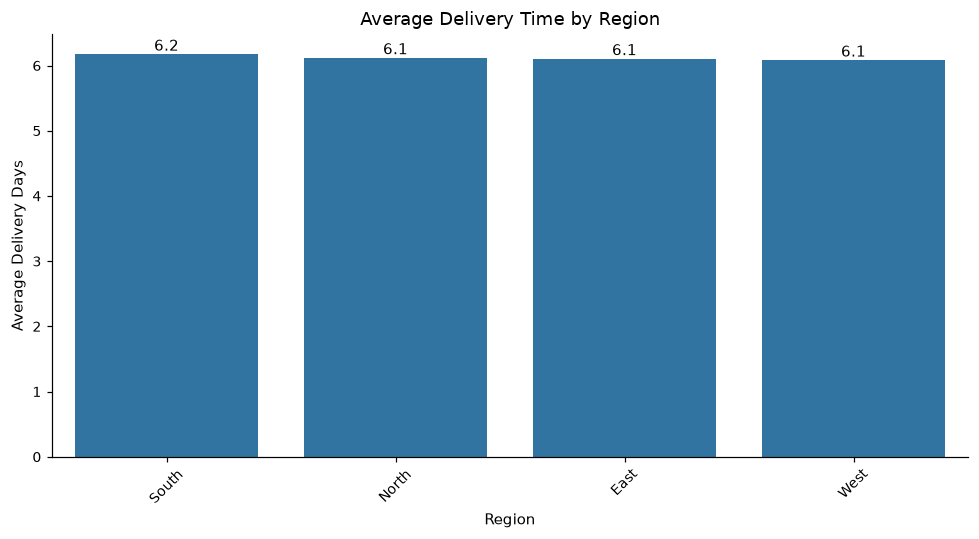

In [71]:
avg_delivery_region = (
    df.groupby("region")["delivery_days"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=avg_delivery_region.index,
    y=avg_delivery_region.values
)

plt.title("Average Delivery Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Delivery Days")

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

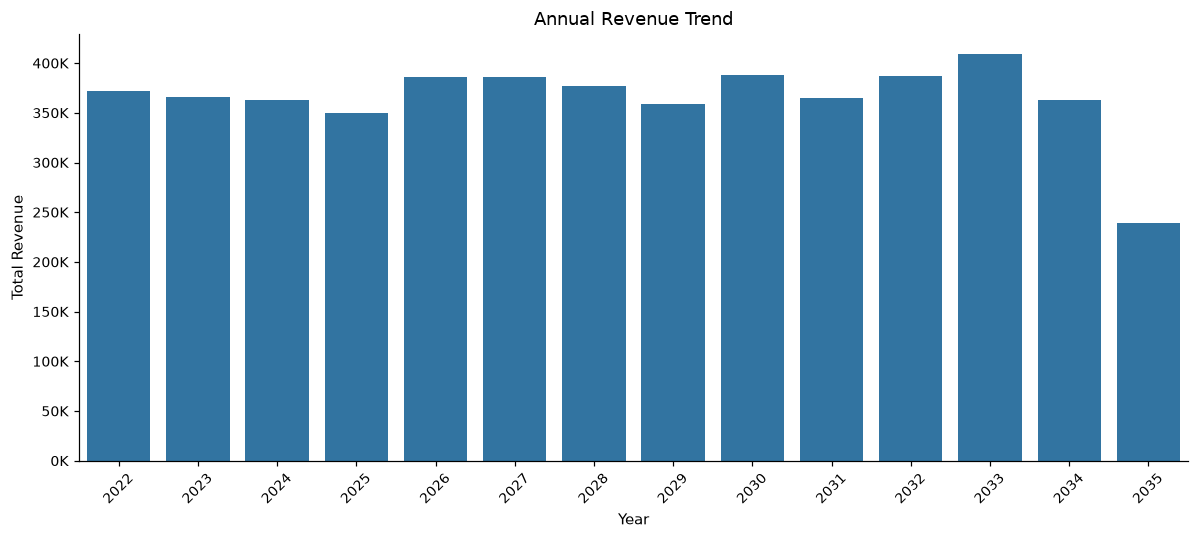

In [72]:
yearly_revenue = (
    df.groupby("order_year")["revenue"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(11, 5))

ax = sns.barplot(
    x=yearly_revenue.index.astype(str),
    y=yearly_revenue.values
)

plt.title("Annual Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Total Revenue")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

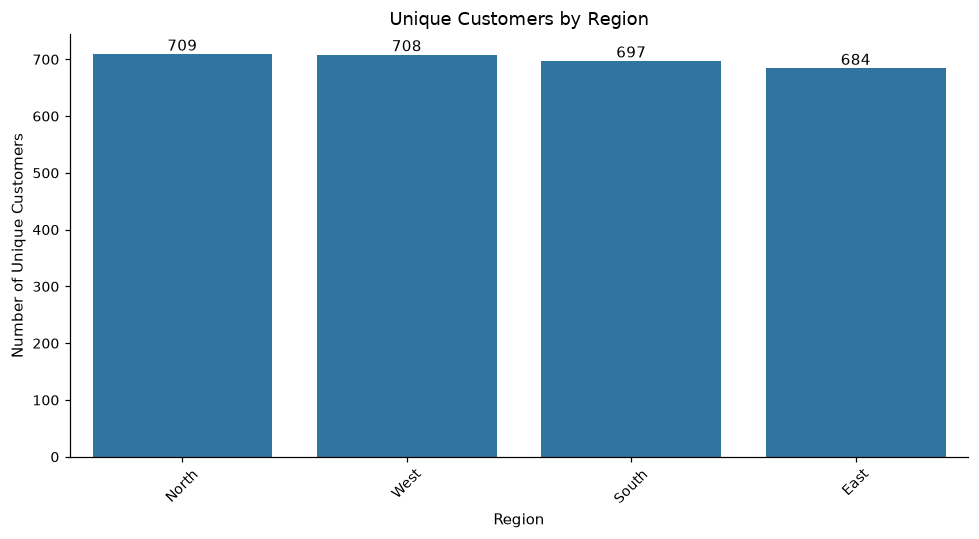

In [73]:
customer_count_region = (
    df.groupby("region")["customer_id"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=customer_count_region.index,
    y=customer_count_region.values
)

plt.title("Unique Customers by Region")
plt.xlabel("Region")
plt.ylabel("Number of Unique Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

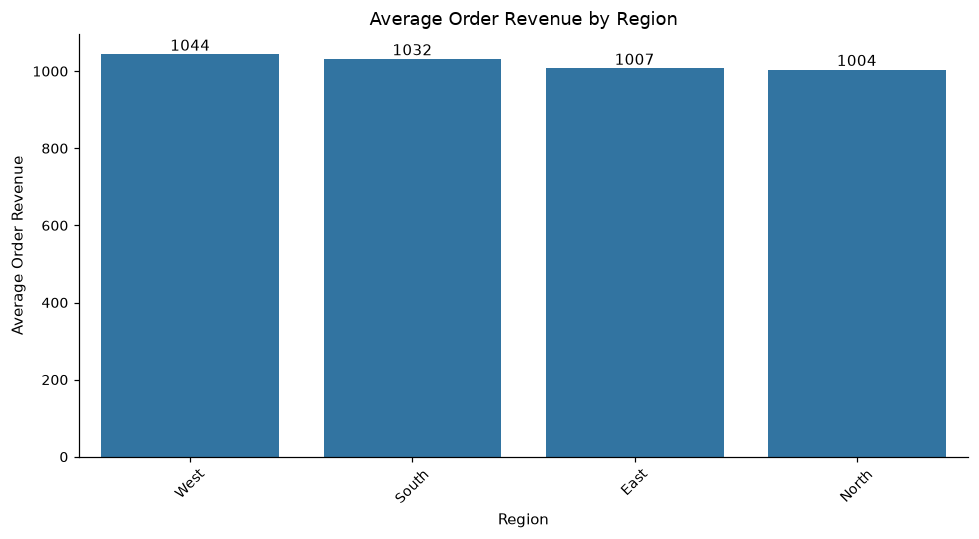

In [74]:
avg_revenue_region = (
    df.groupby("region")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=avg_revenue_region.index,
    y=avg_revenue_region.values
)

plt.title("Average Order Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Average Order Revenue")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

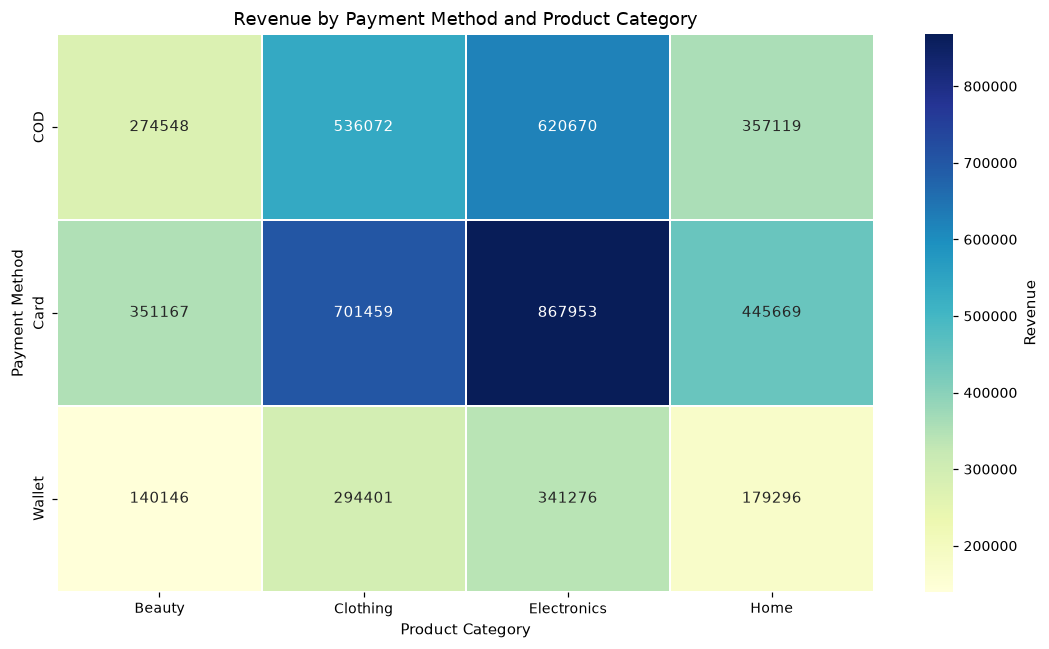

In [75]:
payment_category_revenue = pd.pivot_table(
    df,
    index="payment_method",
    columns="product_category",
    values="revenue",
    aggfunc="sum"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    payment_category_revenue,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Revenue"}
)

plt.title("Revenue by Payment Method and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

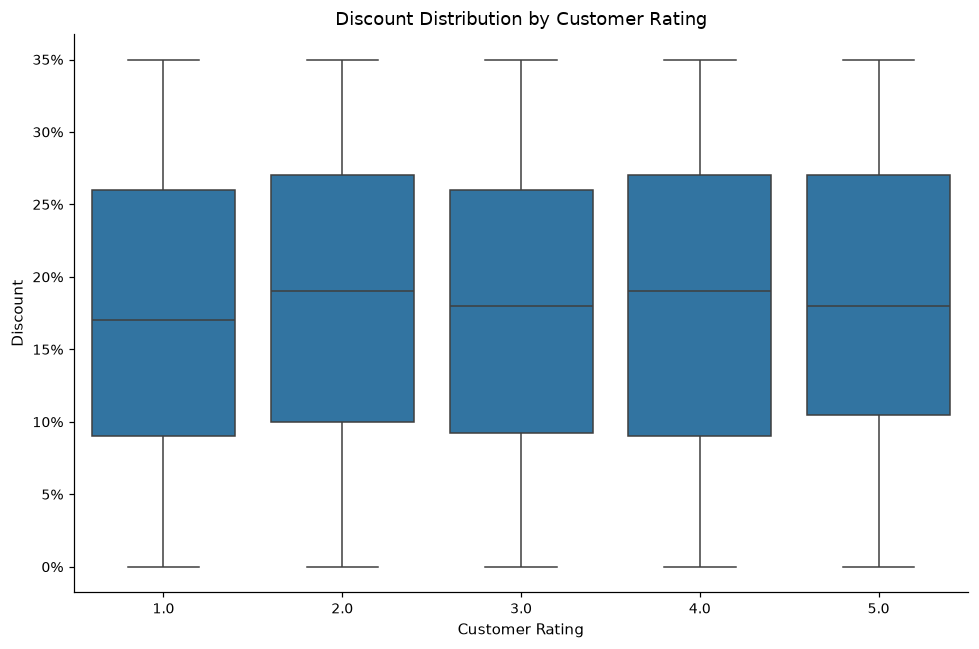

In [76]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="rating_group",
    y="discount"
)

plt.title("Discount Distribution by Customer Rating")
plt.xlabel("Customer Rating")
plt.ylabel("Discount")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x:.0%}")
)

plt.tight_layout()
plt.show()

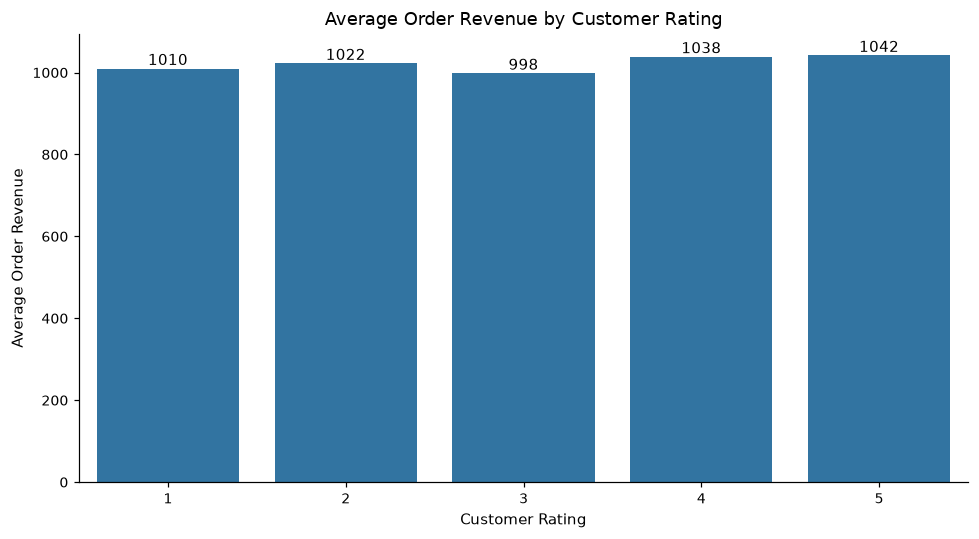

In [77]:
avg_revenue_rating = (
    df.groupby("rating_group")["revenue"]
    .mean()
    .reindex([1, 2, 3, 4, 5])
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=avg_revenue_rating.index,
    y=avg_revenue_rating.values
)

plt.title("Average Order Revenue by Customer Rating")
plt.xlabel("Customer Rating")
plt.ylabel("Average Order Revenue")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

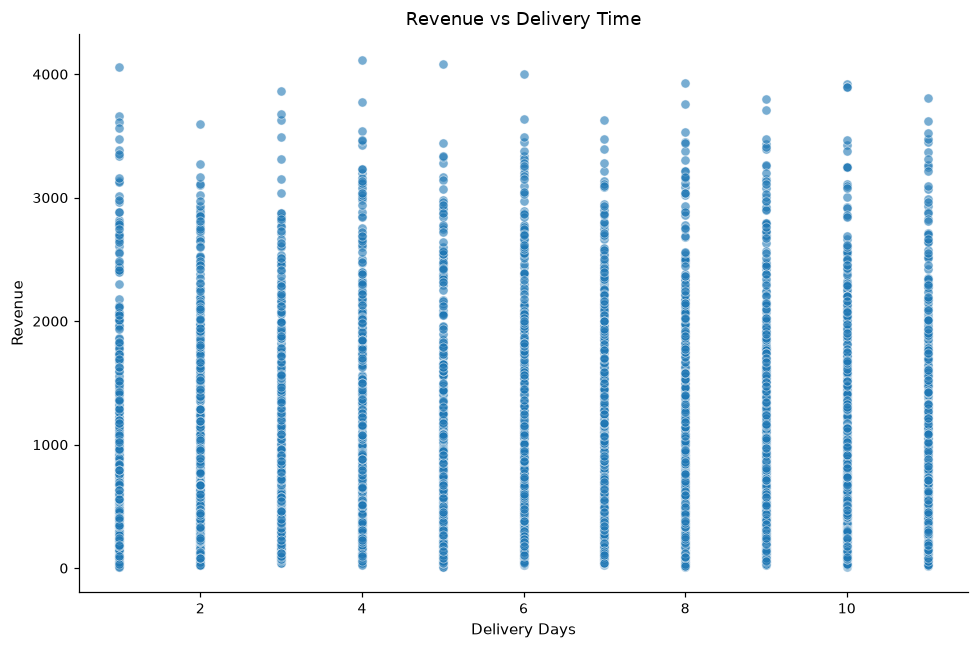

In [78]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="delivery_days",
    y="revenue",
    alpha=0.6
)

plt.title("Revenue vs Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [79]:
output_path = "../data/cleaned/E-Commerce Sales Analytics_Cleaned.csv"

df.to_csv(output_path, index=False)

print("Cleaned CSV saved successfully!")
print(output_path)

Cleaned CSV saved successfully!
../data/cleaned/E-Commerce Sales Analytics_Cleaned.csv
